# Homework 3
## Star Schema and Interactive Dashboard for Financial Transactions

**Datasets:** `symbols.csv`, `account-statement-1-1-2024-12-31-2024.csv`, `country.csv`

### Part 1 - Data Warehouse Modeling: Star Schema

### 1.1 Business Process and Fact Grain Definition

**Business Process:**
The business process under analysis is the management and tracking of financial transactions. Specifically, it monitors the execution of buy and sell orders for listed stocks across different market sectors, industries, and geographic regions.

**Fact Grain:**
One single row in the `Fact_Transactions` table represents **one transaction from the account statement file**. The grain is therefore the single business event (an *event/transaction fact*, as classified in the course slides on logical modeling).

## 1.2 Identify Fact and Dimensions

Based on the provided datasets, each source attribute is assigned either to the fact table or to exactly one dimension table, avoiding any unnecessary duplication of attributes across dimensions (e.g., `country` lives only in `Dim_Geography` and is **not** repeated inside `Dim_Symbol`, even though the source file `symbols.csv` carries it next to the company data).

### 1. Dimension Tables

* **`Dim_Time`** (from the `Date` field of the account statement)
  * `Date` *(natural key)* plus the calendar attributes derived from it (day, month, quarter, year, day of week)

* **`Dim_TransactionType`** (from the `TransactionType` field of the account statement)
  * `TransactionType` *(natural key)*

* **`Dim_Symbol`** (from `symbols.csv`)
  * `Symbol` *(natural key)*
  * `company_name`
  * `industry`
  * `sector`

* **`Dim_Geography`** (from `country.csv`, restricted to the countries that actually appear in `symbols.csv`)
  * `country` *(natural key)*
  * `sub-region`
  * `region`

  I drop `intermediate-region` (and the various ISO code columns) because they are not needed by any of the analyses and `intermediate-region` is empty for most rows.

### 2. Fact Table

* **`Fact_Transactions`**
  * `IDTransaction` *(descriptive attribute kept for traceability towards the source file)*
  * `Date` *(reference to Dim_Time)*
  * `TransactionType` *(reference to Dim_TransactionType)*
  * `Symbol` *(reference to Dim_Symbol)*
  * `country` *(reference to Dim_Geography, derived from the country of the traded company)*
  * `Unit` *(quantitative **measure**: number of units traded, additive via SUM)*


## 1.3 Define Dimension Hierarchies

Based on the dimensions identified in the previous step, the logical hierarchies are defined as follows:

### 1. Time Hierarchy (Dim_Time)
This structure allows time-series analysis and temporal aggregation (e.g., quarterly or monthly reporting).
* **Hierarchy:** Day $\rightarrow$ Month $\rightarrow$ Quarter $\rightarrow$ Year
* The *day of week* attribute is a **descriptive (cross) attribute** of the day level: it does not define an aggregation path on its own, but it supports analyses such as "units sold on Mondays".

### 2. Geography Hierarchy (Dim_Geography)
This hierarchy allows the analyst to explore financial transactions across different geopolitical levels, moving from specific countries up to large geographic areas.
* **Hierarchy:** Country $\rightarrow$ Sub-region $\rightarrow$ Region

### 3. Market/Industry Hierarchy (Dim_Symbol)
This hierarchy enables the aggregation of transaction metrics from individual tickers up to broad economic sectors.
* **Hierarchy:** Symbol $\rightarrow$ Industry $\rightarrow$ Sector
* `company_name` is a descriptive attribute at the Symbol level (a symbol and its company name are at the same level of detail).

### 4. Transaction Type Hierarchy (Dim_TransactionType)
* **Hierarchy:** none — it is a *degenerate* single-level dimension (BUY / SELL / DIVIDENT).

## 1.4 Design the Star Schema

Following the basic translation rule seen in the course slides (*"create a fact table containing all the measures and descriptive attributes directly connected with the fact and, for each hierarchy, create a dimension table containing all of its attributes"*), the final **ROLAP star schema** is:

* **Fact_Transactions** ( <u>TimeId (FK)</u>, <u>SymbolId (FK)</u>, <u>GeoId (FK)</u>, <u>TypeId (FK)</u>, IDTransaction, **Unit** )
* **Dim_Time** ( <u>TimeId (PK)</u>, Date, Day, DayOfWeek, Month, MonthName, Quarter, Year )
* **Dim_Symbol** ( <u>SymbolId (PK)</u>, Symbol, Company, Industry, Sector )
* **Dim_Geography** ( <u>GeoId (PK)</u>, Country, SubRegion, Region )
* **Dim_TransactionType** ( <u>TypeId (PK)</u>, TransactionType )

**Surrogate keys.** Every dimension receives an integer **surrogate key** (`TimeId`, `SymbolId`, `GeoId`, `TypeId`) generated during the ETL phase, instead of using the natural keys of the sources. This is the standard practice recommended in the logical design slides: surrogate keys are compact, stable over time and independent from the (possibly dirty) source values. This choice turned out to be particularly wise here, because during data cleaning (section 2.1) we discovered that `IDTransaction` is **not unique** in the source file, so it cannot be trusted as a key.

**Foreign keys.** Each fact row references exactly one member of each dimension: `TimeId` is derived from the transaction date, `SymbolId` from the traded ticker, `TypeId` from the transaction type and `GeoId` from the country of the company that issued the traded stock (the bridge `symbol` $\rightarrow$ `country` provided by `symbols.csv` is used only at ETL time and is not duplicated in `Dim_Symbol`).

**Measures and descriptive attributes.**
* `Unit` is the only explicit **measure**: it is *additive* (it can be summed along every dimension).
* The **number of transactions** is an implicit measure obtained with COUNT over the fact rows.
* `IDTransaction` is kept as a **descriptive attribute** (a *degenerate* piece of information of the fact): it carries no analytical value but preserves the lineage towards the source file.

The cell below draws the diagram of the star schema (deliverable n. 3) and saves it as `star_schema.png`.

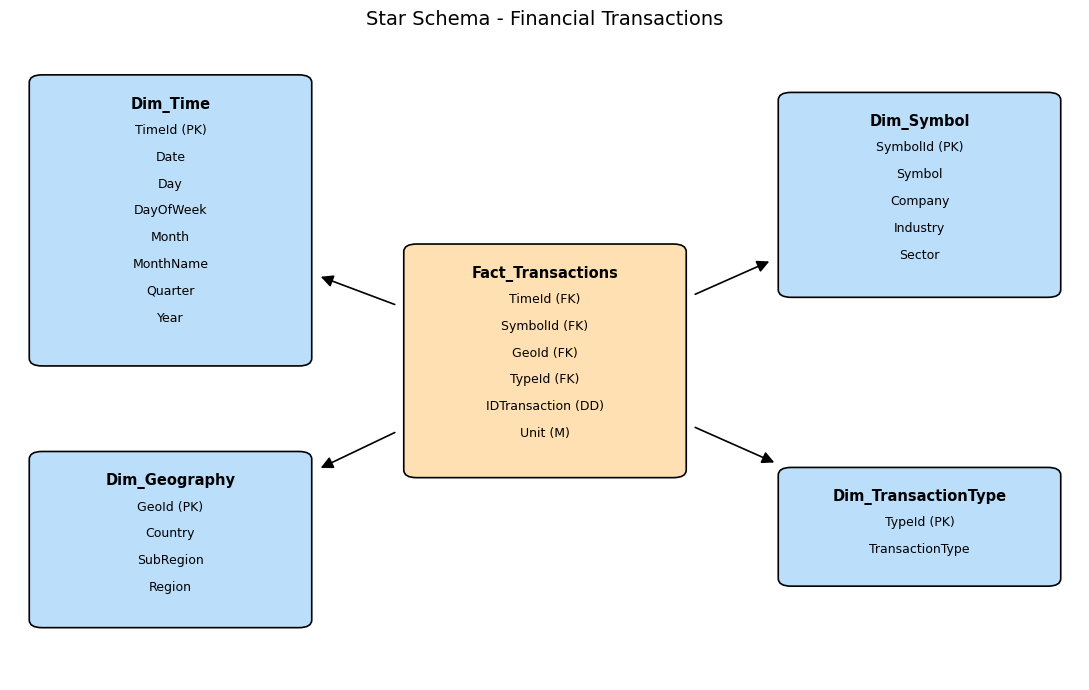

In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


#Star Schema


# We draw the star schema with matplotlib: the fact table sits in the
# middle and the four dimension tables sit around it, each connected to
# the fact table by an arrow (the foreign-key relationship).

# (x, y) centre of each table box, its title and the list of attributes.
# 'PK' marks the surrogate primary key, 'FK' the foreign keys,
# 'M' the measure and 'DD' the degenerate/descriptive attribute.
tables = {
    'Fact_Transactions': {
        'xy': (0.50, 0.50), 'color': '#FFE0B2',
        'rows': ['TimeId (FK)', 'SymbolId (FK)', 'GeoId (FK)', 'TypeId (FK)',
                 'IDTransaction (DD)', 'Unit (M)']},
    'Dim_Time': {
        'xy': (0.15, 0.72), 'color': '#BBDEFB',
        'rows': ['TimeId (PK)', 'Date', 'Day', 'DayOfWeek', 'Month',
                 'MonthName', 'Quarter', 'Year']},
    'Dim_Symbol': {
        'xy': (0.85, 0.76), 'color': '#BBDEFB',
        'rows': ['SymbolId (PK)', 'Symbol', 'Company', 'Industry', 'Sector']},
    'Dim_Geography': {
        'xy': (0.15, 0.22), 'color': '#BBDEFB',
        'rows': ['GeoId (PK)', 'Country', 'SubRegion', 'Region']},
    'Dim_TransactionType': {
        'xy': (0.85, 0.24), 'color': '#BBDEFB',
        'rows': ['TypeId (PK)', 'TransactionType']},
}

fig, ax = plt.subplots(figsize=(11, 7)) #plt.subplots() returns a tuple: figure, area. In In figsize=(), I enter the size in inches
#fig is the sheet, ax  is the area where we draw. 
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off') #I’ve set the x-axis limits to 0 to 1, the same for the y-axis and I’m removing the axes from the drawing


        
sizes = {}                                       # empty dict: will store each box size (w,h), needed later for the arrows
for name, spec in tables.items():                # loop over the 5 tables: name = table name, spec = its dict {xy, color, rows}
    cx, cy = spec['xy']                          # unpack the box centre: cx = centre-x, cy = centre-y
    n_rows = len(spec['rows'])                    # count the table's attributes (used to size the box height)
    w, h = 0.24, 0.045 * (n_rows + 1.6)          # w = fixed width; h = height that grows with the number of rows
    sizes[name] = (w, h)                          # remember this box size under the table name
    # rounded rectangle for the table
    box = FancyBboxPatch((cx - w / 2, cy - h / 2), w, h,   # build the rectangle: from the centre get the bottom-left corner (centre - half size)
                         boxstyle='round,pad=0.012',        # rounded corners with a small inner padding
                         facecolor=spec['color'], edgecolor='black', linewidth=1.2)  # fill colour, black border, border thickness
    ax.add_patch(box)                             # add the built rectangle to the drawing area
    # table name (bold) on the first line, then one line per attribute
    ax.text(cx, cy + h / 2 - 0.035, name, ha='center', va='center',   # write the table NAME near the top (cy+h/2 = top edge, -0.035 nudges down)
            fontsize=10.5, fontweight='bold')     # larger, bold font: it is the heading
    for i, attr in enumerate(spec['rows']):       # loop over attributes: i = running index (0,1,2...), attr = attribute text
        ax.text(cx, cy + h / 2 - 0.075 - i * 0.042, attr,   # write the attribute; -0.075 places it below the title, -i*0.042 drops one row each time
                ha='center', va='center', fontsize=9)        # centred on the point (horiz. and vert.), smaller font
        



def edge_point(c_from, c_to, box_size, margin=0.018):   # function: find the point on the EDGE of the box centred in c_to, coming from c_from
    """Point where the segment c_from -> c_to crosses the border of the box
    centred in c_to (so arrows start/end exactly on the box edges)."""
    (x0, y0), (x1, y1) = c_from, c_to             # unpack coordinates: (x0,y0) = start, (x1,y1) = end
    vx, vy = x1 - x0, y1 - y0                      # direction vector start->end: displacement in x (vx) and y (vy)
    w2, h2 = box_size[0] / 2 + margin, box_size[1] / 2 + margin   # half-width and half-height of the target box (+ margin gap)
    # fraction of the segment at which each side of the box is reached
    tx = (abs(vx) - w2) / abs(vx) if vx != 0 else 1   # t (0=start,1=centre) at which the VERTICAL sides are hit; if vx=0 -> 1 (neutral)
    ty = (abs(vy) - h2) / abs(vy) if vy != 0 else 1   # t at which the HORIZONTAL sides are hit; if vy=0 -> 1 (neutral)
    t = max(tx, ty)                              # enter the rectangle at the larger of the two: BOTH limits must be met
    return (x0 + t * vx, y0 + t * vy)             # apply that t to the segment: return the exact point on the edge

    


# arrows: fact table -> each dimension (FK relationships)
f_center = tables['Fact_Transactions']['xy']      # centre of the fact (0.50, 0.50): fixed point where all arrows start
for dim in ['Dim_Time', 'Dim_Symbol', 'Dim_Geography', 'Dim_TransactionType']:   # loop over the 4 dimensions
    d_center = tables[dim]['xy']                  # centre of the current dimension
    start = edge_point(d_center, f_center, sizes['Fact_Transactions'])  # start point: on the edge of the FACT box
    end = edge_point(f_center, d_center, sizes[dim])                    # end point: on the edge of the DIMENSION box
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle='-|>',          # build the edge-to-edge arrow, triangular head '-|>'
                                 mutation_scale=18, color='black', linewidth=1.2))  # head size, colour and thickness; add it to the canvas



plt.title('Star Schema - Financial Transactions', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('star_schema.png', dpi=150, bbox_inches='tight')   # deliverable n.3
plt.show()
